# Flow Matching for 2D Jellyfish Control — `lab_five`

Companion to `lab_four.ipynb` (Burgers 1D, DiffPhyCon Experiment 1).

This lab is the **toy / local** version of paper Experiment 3 (2D jellyfish control):

- Smaller `Unet3D` ($\dim = 32$, $\dim\_mults = (1,2)$, ~1.9M params vs paper's 22M)
- Trains on the 200 test_data samples (split 160 train / 40 eval), instead of the full 30k-sample training set that lives on Modal
- **Skips** prior-reweighting + LilyPad eval (those are `lab_five_modal.py` future work)
- Designed to run end-to-end on M4 Pro MPS in one overnight

**Why toy**: verify FM scaffolding works on 3D (T, H, W) data layout and learn how jellyfish data + Unet3D differ from Burgers. Paper-faithful Table 28 comparison needs Modal A100.

## How to use this lab

1. Read the markdown cell at the top of each Part.
2. Find each `# Question N.M` cell and **fill in** the methods marked `raise NotImplementedError(...)`. Each fill-in has a `# Step N:` comment that says exactly what to compute.
3. After each Part, **run the sanity check cell**.
4. When all sanity checks pass, run `train_jellyfish_for_part5(num_steps=15000)` (overnight on M4 Pro), then use Part 5 helpers to visualize.

## ⚠️ Data layout — `(b, T, C, H, W)` not `(b, C, T, H, W)`

`Unet3D_with_Conv3D.forward` internally does `x.permute(0, 2, 1, 3, 4)`, so it expects input in `(b, T, C, H, W)`. **The channel dim is dim 2, not dim 1.**

This means:
- `z` has shape `(b, 20, 4, 64, 64)` — 4 channels (state vx/vy/pressure + theta-broadcast)
- `c` has shape `(b, 20, 3, 64, 64)` — 3 channels (bd mask + 2 offsets), pre-padded 62→64
- **`torch.cat([x, c], dim=2)`** when injecting boundary — NOT `dim=1` (which would concat over time)
- `t` (FM time) shape `(b, 1, 1, 1, 1)` for broadcasting

This is the only **systematic difference** from `lab_four`. Most fill-ins are just `lab_four` with shape `(b, 1, 1, 1, 1)` instead of `(b, 1, 1, 1)`.

## Background reading

- `flow/lab_four.py` — the Burgers FM lab this mirrors (abstractions imported from there)
- `LILYPAD_DEEP_DIVE.md` — jellyfish eval pipeline (used in `lab_five_modal.py` future work)
- `notes_diffphycon_flow_bridge.md` — DDPM ↔ FM translation
- `train/train_2d_jellyfish.py` — paper DDPM trainer (we mirror the model arch)


In [1]:
# pyright: reportUnknownMemberType=false
from __future__ import annotations
import math
import os
import pickle
import sys
from typing import Tuple, Optional

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
# --- path setup (works as .py or in Jupyter notebook) ---
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.path.abspath(os.getcwd())
    if os.path.basename(HERE) != "flow":
        HERE = os.path.join(HERE, "flow")
ROOT = os.path.dirname(HERE)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Part 0: Setup + Re-imports

We **reuse all the FM scaffolding from lab_four**:

- `Sampleable` / `LabeledSampleable` — distribution ABCs
- `ConditionalProbabilityPath` / `GaussianConditionalProbabilityPath` — Gaussian path with $\alpha_\tau = \tau, \beta_\tau = 1 - \tau$
- `LinearAlpha` / `LinearBeta` — schedules
- `VectorFieldNet` — ABC for velocity-field networks
- `Trainer` — generic FM training loop (tqdm + loss_history)
- `EMA` / `finetune_with_ema` — optional EMA helpers

Then we import jellyfish-specific repo modules:

- `Unet3D_with_Conv3D` from `model/video_diffusion_pytorch/video_diffusion_pytorch_conv3d.py` — the 3D conv backbone (same architecture as paper DDPM, just smaller).

**No fill-ins in Part 0.**

In [4]:
from flow.lab_four import (
    Sampleable,
    LabeledSampleable,
    ConditionalProbabilityPath,
    GaussianConditionalProbabilityPath,
    LinearAlpha,
    LinearBeta,
    VectorFieldNet,
    Trainer,
    EMA,
    finetune_with_ema,
)

/opt/homebrew/Caskroom/miniconda/base/envs/diffphycon/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/baochen/diffphycon/diffusion/diffusion_1d_burgers.py:730: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)


In [5]:
from model.video_diffusion_pytorch.video_diffusion_pytorch_conv3d import Unet3D_with_Conv3D

### Jellyfish-specific constants + data loader

In [6]:
JELLYFISH_DATA_PATH = os.path.join(ROOT, "data", "jellyfish")
H, W = 64, 64               # spatial size of state
BD_H, BD_W = 62, 62         # spatial size of raw boundary (pad to 64)
T_FRAMES = 20               # FM operates on 20-frame windows (first 20 of 40)
TRAJ_LEN = 40               # each sim has 40 total frames
N_TOTAL = 200               # 200 sims available in test_data/
N_TRAIN = 160
N_EVAL = 40
THETA_NORM = 1.6            # rad — empirically θ ∈ [-π/2, π/2] approx; this normalizes to [-1, 1]

In [7]:
def load_jellyfish_normalization() -> dict:
    """Load (vx/vy/pressure)_max/min from the pkl that paper provides."""
    p = os.path.join(JELLYFISH_DATA_PATH, "test_data", "normalization_max_min.pkl")
    if not os.path.isfile(p):
        raise FileNotFoundError(
            f"Missing {p}. Expected normalization pkl from paper data dump."
        )
    return pickle.load(open(p, "rb"))

In [8]:
def _load_one_sim(sim_id: int, norm: dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load one sim's (state, bd_mask_offset, theta) — all unbatched, numpy."""
    base = os.path.join(JELLYFISH_DATA_PATH, "test_data")

    # state: (40, 3, 64, 64) raw → normalize each channel to [-1, 1]
    state = np.load(os.path.join(base, f"states/sim_{sim_id:06d}.npz"))["a"].astype(np.float32)
    vx_lo, vx_hi = norm["vx_min"], norm["vx_max"]
    vy_lo, vy_hi = norm["vy_min"], norm["vy_max"]
    p_lo,  p_hi  = norm["p_min"],  norm["p_max"]
    state[:, 0] = np.clip((state[:, 0] - vx_lo) / (vx_hi - vx_lo), 0, 1) * 2 - 1
    state[:, 1] = np.clip((state[:, 1] - vy_lo) / (vy_hi - vy_lo), 0, 1) * 2 - 1
    state[:, 2] = np.clip((state[:, 2] - p_lo)  / (p_hi  - p_lo),  0, 1) * 2 - 1
    state = np.nan_to_num(state, nan=0.0)

    # bd_mask_offset: raw (40, 62, 62, 3) → transpose to (40, 3, 62, 62)
    bd = np.load(os.path.join(base, f"bdry_merged_mask_offsets/sim_{sim_id:06d}.npz"))["a"]
    bd = np.transpose(bd, (0, 3, 1, 2)).astype(np.float32)
    bd = np.nan_to_num(bd, nan=0.0)

    # theta: (40,) — normalize to [-1, 1] using THETA_NORM
    theta = np.load(os.path.join(base, f"bdry_head_thetas/sim_{sim_id:06d}.npz"))["thetas"].astype(np.float32)
    theta = theta / THETA_NORM

    return state, bd, theta

In [9]:
def load_jellyfish_all(verbose: bool = True):
    """Load all 200 sims into RAM. Returns 3 numpy arrays."""
    norm = load_jellyfish_normalization()
    states = np.zeros((N_TOTAL, TRAJ_LEN, 3, H, W), dtype=np.float32)
    bds    = np.zeros((N_TOTAL, TRAJ_LEN, 3, BD_H, BD_W), dtype=np.float32)
    thetas = np.zeros((N_TOTAL, TRAJ_LEN), dtype=np.float32)
    for i in range(N_TOTAL):
        s, b, t = _load_one_sim(i, norm)
        states[i] = s; bds[i] = b; thetas[i] = t
        if verbose and (i + 1) % 50 == 0:
            print(f"  loaded {i+1}/{N_TOTAL} sims")
    return states, bds, thetas

In [10]:
def split_train_eval(states, bds, thetas, seed: int = 42):
    """Deterministic 160 / 40 split."""
    rng = np.random.RandomState(seed)
    idx = rng.permutation(N_TOTAL)
    tr, ev = idx[:N_TRAIN], idx[N_TRAIN:]
    return ((states[tr], bds[tr], thetas[tr]),
            (states[ev], bds[ev], thetas[ev]))

# Part 1: Get a Feel for Jellyfish Data

Like `lab_four` Part 1, we visualize the data before building any models.

Each jellyfish simulation has **40 frames** of:

- **state** $(40, 3, 64, 64)$ — channels are $(v_x, v_y, p)$ (velocity x/y + pressure)
- **boundary mask + offsets** $(40, 3, 62, 62)$ — describes where the jellyfish wings are at each frame (mask + horizontal/vertical offset)
- **θ** $(40,)$ — the wing rotation angle (the control variable)

We work with the **first 20 frames** of each sim → 20-frame windows.

**No fill-ins in Part 1.**

In [11]:
def visualize_jellyfish_sample(
    state: np.ndarray,   # (20, 3, 64, 64) — normalized [-1, 1]
    bd:    np.ndarray,   # (20, 3, 62, 62)
    theta: np.ndarray,   # (20,) — normalized
    title: str = "",
    save_path: Optional[str] = None,
):
    """4-row plot:
        row 0: vx        at t={0, 5, 10, 15, 19}
        row 1: vy        at t={0, 5, 10, 15, 19}
        row 2: pressure  at t={0, 5, 10, 15, 19}
        row 3: bd_mask   at t={0, 5, 10, 15, 19}  (channel 0 of bd)
       Plus θ vs t line plot at bottom.
    """
    import matplotlib.pyplot as plt
    cols = [0, 5, 10, 15, 19]
    fig, axes = plt.subplots(5, 5, figsize=(15, 14))
    row_labels = ["vx", "vy", "pressure", "bd_mask", ""]
    for r, label in enumerate(row_labels[:4]):
        for ci, t_idx in enumerate(cols):
            ax = axes[r, ci]
            if r < 3:
                img = state[t_idx, r]
            else:
                img = bd[t_idx, 0]   # boundary mask
            im = ax.imshow(img, cmap="RdBu_r", vmin=-1, vmax=1)
            ax.set_title(f"{label} t={t_idx}", fontsize=9)
            ax.axis("off")
    # θ vs t plot on the last row (spans 5 cols, but we just use middle)
    for ci in range(5):
        axes[4, ci].axis("off")
    ax_theta = fig.add_subplot(5, 1, 5)
    ax_theta.plot(np.arange(20), theta * THETA_NORM, "o-", linewidth=2)
    ax_theta.axhline(0, color="gray", lw=0.5)
    ax_theta.set_xlabel("frame")
    ax_theta.set_ylabel("θ (rad)")
    ax_theta.set_title("Wing angle over time (un-normalized)")
    ax_theta.grid(True, alpha=0.3)
    if title:
        fig.suptitle(title, fontsize=14, y=0.99)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        print(f"  saved {save_path}")
    plt.show()

In [12]:
def sanity_check_part1():
    """Load + visualize 2 sims to confirm data shape."""
    print("\n=== Sanity Check Part 1: Jellyfish data ===")
    print(f"  Loading {N_TOTAL} sims (this takes ~10 sec)...")
    states, bds, thetas = load_jellyfish_all(verbose=False)
    print(f"  shapes:  states={states.shape}  bds={bds.shape}  thetas={thetas.shape}")
    print(f"  state  range: [{states.min():.3f}, {states.max():.3f}]")
    print(f"  bd     range: [{bds.min():.3f}, {bds.max():.3f}]")
    print(f"  theta  range (normalized): [{thetas.min():.3f}, {thetas.max():.3f}]")
    print(f"  theta  range (un-normalized rad): [{(thetas*THETA_NORM).min():.3f}, {(thetas*THETA_NORM).max():.3f}]")

    for idx in [0, 100]:
        visualize_jellyfish_sample(
            states[idx, :T_FRAMES],
            bds[idx, :T_FRAMES],
            thetas[idx, :T_FRAMES],
            title=f"Jellyfish sim_{idx:06d} (first 20 frames)",
            save_path=os.path.join(HERE, f"lab_five_part1_sim{idx}.png"),
        )
    print("  ✅ Part 1 visualization done.")


=== Sanity Check Part 1: Jellyfish data ===
  Loading 200 sims (this takes ~10 sec)...
  shapes:  states=(200, 40, 3, 64, 64)  bds=(200, 40, 3, 62, 62)  thetas=(200, 40)
  state  range: [-0.772, 0.752]
  bd     range: [-0.500, 1.000]
  theta  range (normalized): [0.118, 0.652]
  theta  range (un-normalized rad): [0.188, 1.043]
  saved /Users/baochen/diffphycon/flow/lab_five_part1_sim0.png


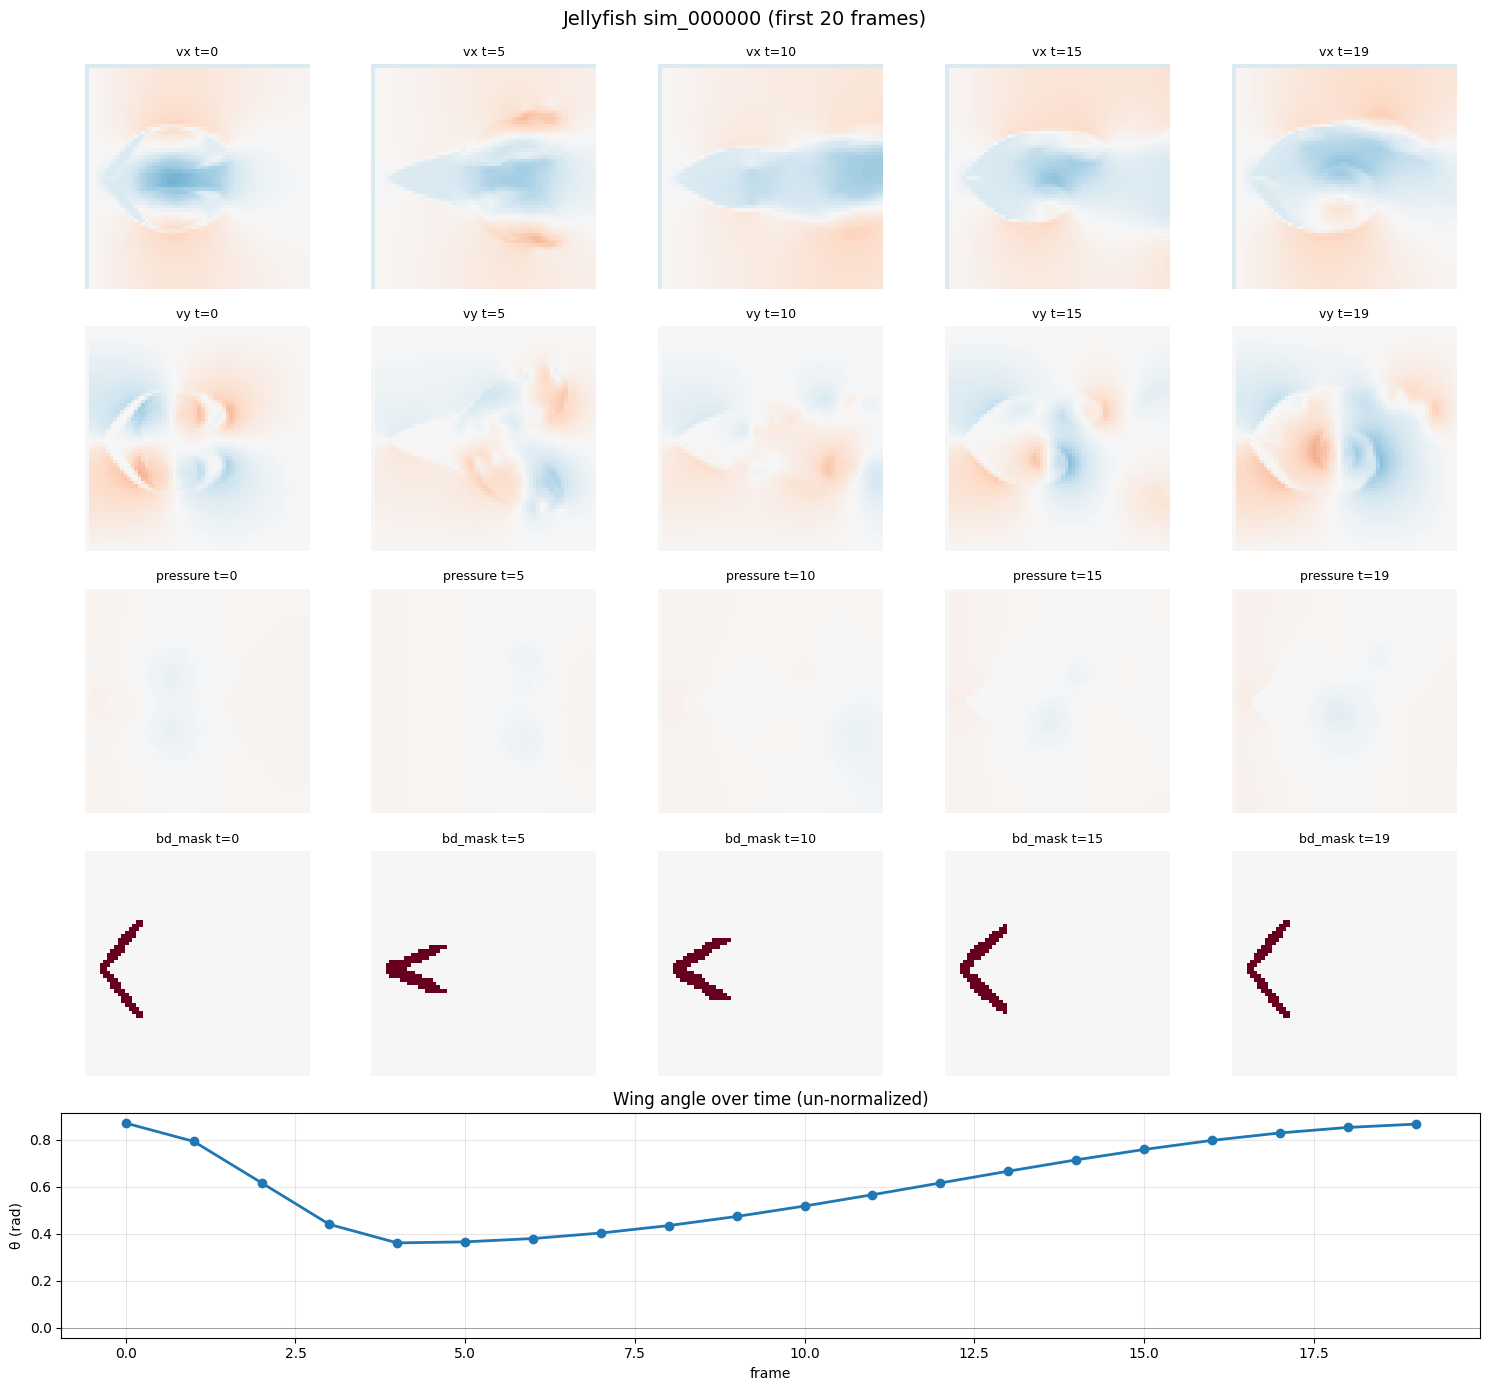

  saved /Users/baochen/diffphycon/flow/lab_five_part1_sim100.png


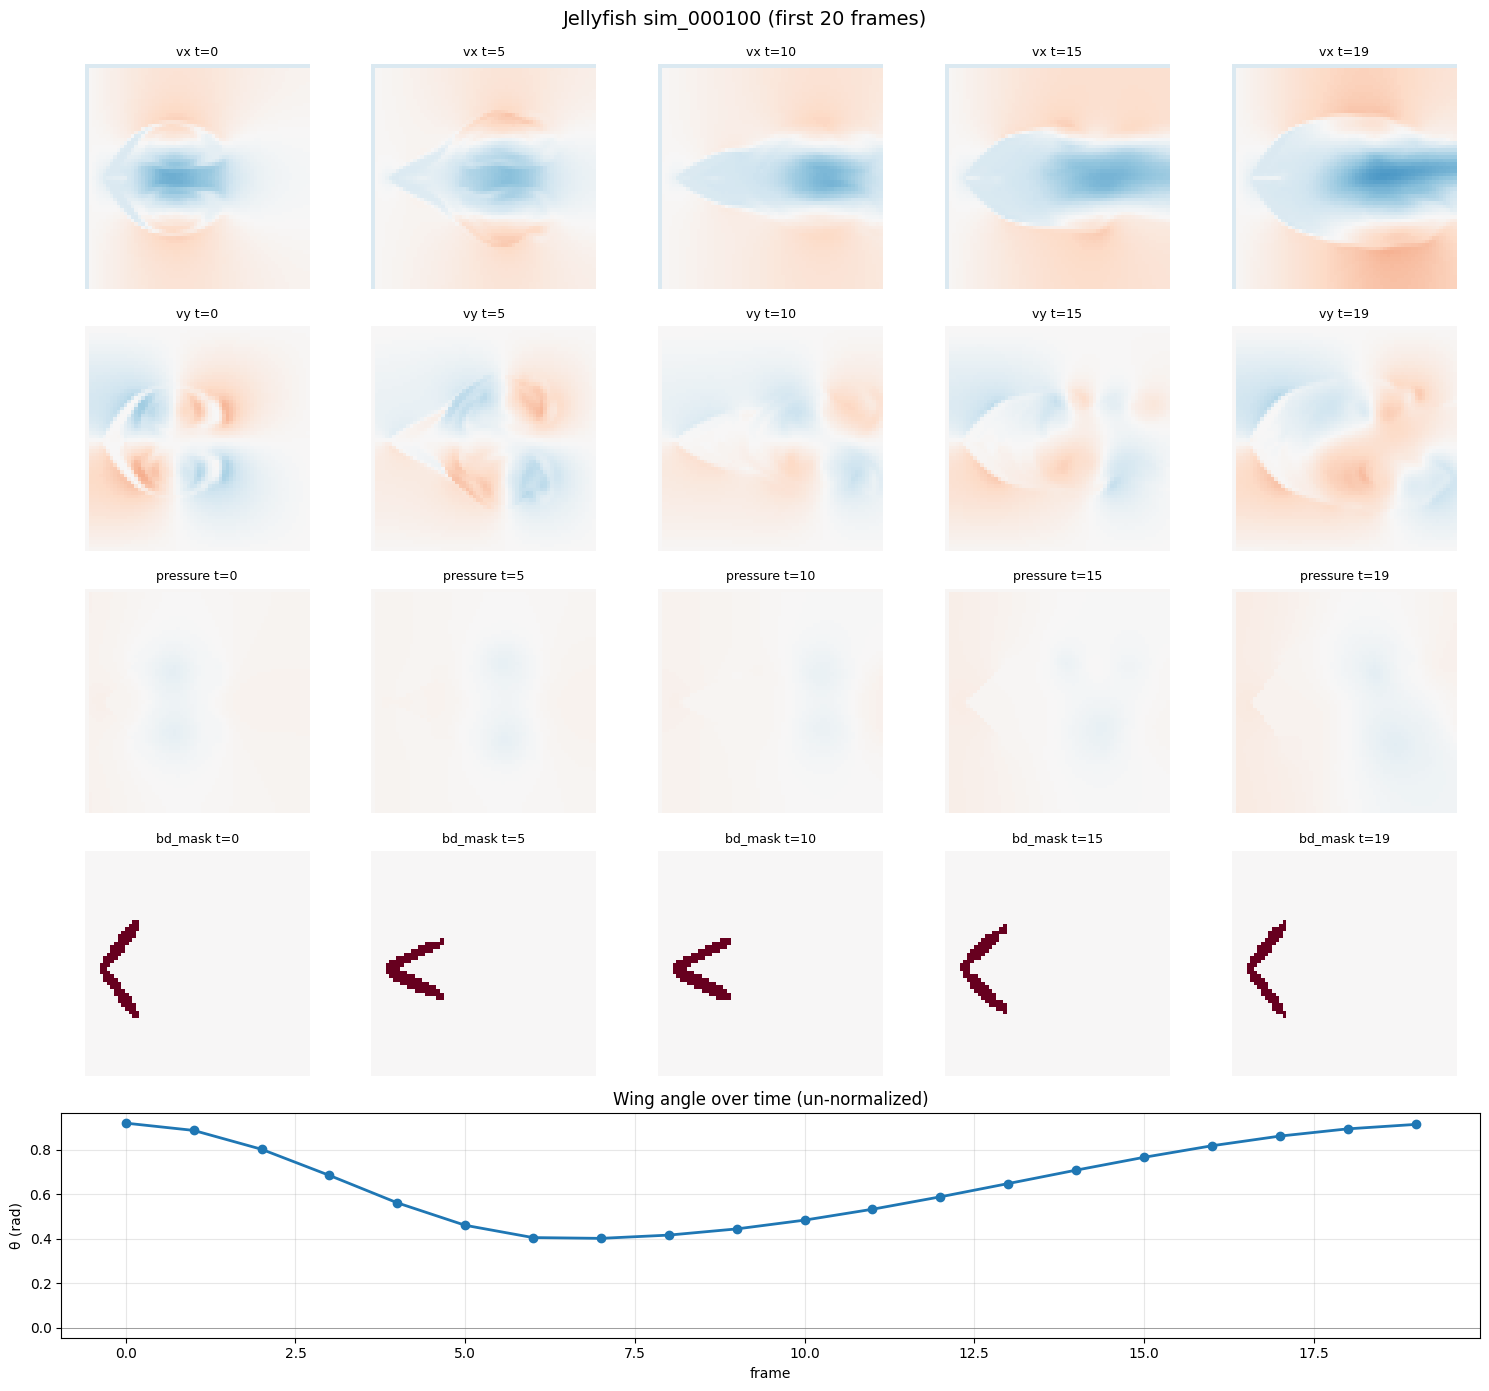

  ✅ Part 1 visualization done.


In [13]:
sanity_check_part1()

# Part 2: Train Joint FM (Q5.1 - Q5.4)

**Goal**: learn the velocity field $u_\tau^\theta(z \mid c)$ of the joint distribution $p(\text{state}, \theta \mid \text{boundary})$ over jellyfish trajectories.

**Three classes to fill in**:

- **Q5.1** — `JellyfishDataset.sample` (3 Steps) — extract 20-frame windows, pack into $(z, c)$
- **Q5.2** — `JellyfishFlowTrainer.get_train_loss` (5 Steps) — CFM loss, same as `lab_four` Q2.2 but 5D
- **Q5.3** — `JellyfishVectorField.forward` (3 Steps) — wraps `Unet3D`, concat $c$ along **dim=2**

**Key differences vs `lab_four`**:

| | Burgers (`lab_four`) | Jellyfish (this lab) |
|:---|:---|:---|
| $z$ shape | $(b, 2, 16, 128)$ | $(b, 20, 4, 64, 64)$ |
| $c$ injection | inpaint_overwrite (replace rows) | concat on channel dim=2 |
| $c$ scope | 2 slices (initial + terminal $u$) | full 20-frame boundary trajectory |
| FM time $t$ shape | $(b, 1, 1, 1)$ | $(b, 1, 1, 1, 1)$ |
| Inpainting trick on `u_target` | yes (Step 5 of Q2.2) | **no** — $c$ never noised, lives outside $x$ |

After filling, run `sanity_check_2_4()` — loss should drop to ~0.5 in 200 steps.

## What `z` and `c` are — packaging the 3 raw tensors into 2 FM inputs

You've seen the 3 raw tensors per sim:

- `state` $(40, 3, 64, 64)$ — water flow (vx, vy, pressure)
- `bd_mask_offset` $(40, 3, 62, 62)$ — where the wings are
- `theta` $(40,)$ — wing angle scalar per frame

But FM wants just **two** things:

| FM concept | Role | What it contains | Shape |
|:---|:---|:---|:---|
| **z** | the thing we GENERATE (output) | state + θ-broadcast | $(b, 20, 4, 64, 64)$ |
| **c** | the thing we're CONDITIONED on (input) | bd_mask + offsets | $(b, 20, 3, 64, 64)$ |

In words: **"given the wing position trajectory (c), generate the water flow and the angle sequence (z)"**.

### Why `state` AND `θ` both go into `z`?

Physically `state` is a *result* (water gets pushed by the wings) and `θ` is a *cause* (control variable). But FM doesn't care about causality — it learns the **joint distribution** $p(\text{state}, \theta \mid \text{boundary})$.

Think of it like GPT generating an A/B dialogue — it doesn't know who "speaks first", it just learns the joint over the whole conversation. Same here: state and θ are generated together as one $z$.

(The full Modal version of this lab will add a **second** model that learns the marginal $p(\theta \mid \text{boundary})$ — the "prior" — then γ-reweights joint and prior at sampling time to bias θ toward "fast-swimming" patterns. That's Part 4 we're skipping in toy mode.)

### Why does θ get "broadcast" to 64×64? (the key trick)

`state` is a (64, 64) image per channel. `θ[t]` is a single scalar. They can't be `torch.cat`-ed because shapes don't match.

**The fix**: pretend θ is also a (64, 64) image — just fill the entire image with the scalar value.

```python
theta[t] = 0.871           # one scalar

# After broadcast:
theta_bcast[t] = a (64, 64) image where every pixel = 0.871
# Looks like:
#   0.871  0.871  0.871  ...  0.871
#   0.871  0.871  0.871  ...  0.871
#   ...
#   0.871  0.871  0.871  ...  0.871
```

Visually it's a flat color, but the shape now matches `state`'s channels. We `cat` them as channel 4:

```
state         (40, 3, 64, 64)   ← 3 channels: vx, vy, p
theta_bcast   (40, 1, 64, 64)   ← 1 channel: pixel value = θ
z = cat       (40, 4, 64, 64)   ← 4 channels: vx, vy, p, θ
```

### Why this works for the network

Unet3D sees a "θ channel" that is a flat color per frame. **A flat color carries no spatial information (every pixel identical) but carries temporal info (color changes frame-to-frame)** — exactly what we want, because θ is a per-frame scalar.

The temporal attention layers inside Unet3D pick up "this frame has θ = 0.871, next frame θ = 0.793". This is the standard trick paper DDPM also uses (`train_2d_jellyfish.py` has 7-channel input = state(3) + bd(3) + θ-broadcast(1)).

### Why does `c` not need broadcast?

Because `bd_mask_offset` is already a per-pixel image — each pixel has its own mask/offset value (real spatial information). We only `F.pad` it from 62×62 → 64×64 to match `state`.

### TL;DR

| What | Why this shape |
|:---|:---|
| **z** = state + θ-broadcast → $(b, 20, 4, 64, 64)$ | θ is a scalar; broadcast it to a flat (64, 64) image so it can stack with state |
| **c** = boundary, padded → $(b, 20, 3, 64, 64)$ | already an image; just pad 62→64 |
| FM learns | velocity field $v_\tau(z \mid c)$ — i.e. how to denoise (state, θ) given (boundary) |

The Q5.1 fill-in code in the next cell is literally just this packaging — once you grok this section, the Q5.1 hints will read like obvious one-liners.


## ⚠️ The 5D layout gotcha (read before Q5.1!)

`Unet3D_with_Conv3D.forward` does this on its first line:

```python
def forward(self, x, time, cond=None, ...):
    x = x.permute(0, 2, 1, 3, 4)   # swaps dim 1 and dim 2
```

So **it expects input in `(b, T, C, H, W)`**, not the "natural" `(b, C, T, H, W)`.

If you pass `(b, C, T, H, W)` by Burgers-instinct, you'll see an error like:

```
RuntimeError: Given groups=1, weight of size [32, 7, 7, 7, 7],
expected input[1, 20, 7, 64, 64] to have 7 channels, but got 20 channels instead
```

(it treats your time dim as channels and gets the wrong count)

**Throughout this lab**:
- `z` is `(b, T=20, C=4, H=64, W=64)` — channel dim is **dim=2**
- `c` is `(b, T=20, C=3, H=64, W=64)` — channel dim is **dim=2**
- Concat them: `torch.cat([z, c], dim=2)` → `(b, 20, 7, 64, 64)`
- Theta broadcast: `theta[:, :, None, None, None].expand(-1, T, 1, H, W)` → `(b, 20, 1, 64, 64)`

The cached data in `JellyfishDataset` is already in `(N, 40, 3, 64, 64)` per-sim layout = `(N, T, C, H, W)`, so you don't need any `.permute()` calls in Q5.1.

This matches `dataset/data_2d.py::Jellyfish` (the paper's dataset class) and `train/train_2d_jellyfish.py` (the paper's trainer).

## Question 5.1 — `JellyfishDataset.sample`

Build the data sampler. For each batch, return:

- `z` of shape $(b, 20, 4, 64, 64)$ — joint = state (3 channels) + theta-broadcast (1 channel)
- `c` of shape $(b, 20, 3, 64, 64)$ — boundary mask+offsets, **padded from 62×62 → 64×64**

⚠️ **Channel dim is dim=2** (not dim=1!) — see top-of-file layout note.

**3 fill-in Steps**.

In [ ]:
class JellyfishDataset(LabeledSampleable):
    """Wraps the 160-sim train pool, exposes (z, c) batches.

    z: (b, 20, 4, 64, 64) — state (3) + theta-broadcast (1), layout (b,T,C,H,W)
    c: (b, 20, 3, 64, 64) — bd_mask_offset, padded from 62×62 to 64×64

    Design note:
      Unlike Burgers (c = 2 boundary slices, injected via inpaint_overwrite),
      jellyfish c is the **full boundary trajectory** over all 20 frames.
      The boundary changes every frame as the wings rotate. So we treat c
      as auxiliary input channels concat'd to x in `JellyfishVectorField.forward`.
    """
    def __init__(self, states: np.ndarray, bds: np.ndarray, thetas: np.ndarray,
                 device: str = "cpu"):
        # all tensors live on `device`. Pre-convert + cache.
        # states: (N, 40, 3, 64, 64) — keep on CPU until sampled (saves device memory)
        self.states = torch.from_numpy(states).to(device)
        self.bds    = torch.from_numpy(bds).to(device)
        self.thetas = torch.from_numpy(thetas).to(device)
        self.N = states.shape[0]
        self.device = device

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            z: (num_samples, 20, 4, 64, 64) — joint = state + theta-broadcast
            c: (num_samples, 20, 3, 64, 64) — boundary padded to 64×64
        """
        # Step 1: Uniformly sample `num_samples` indices in [0, self.N).
        #         Use them to gather state, bd, theta windows of length T_FRAMES=20
        #         from the FIRST T_FRAMES frames of each sampled sim.
        #
        # The cached tensors are already in (T, C, H, W) per-sim layout, so
        # `self.states[idx]` returns (b, 40, 3, 64, 64) = (b, T_total, C, H, W).
        # No permute needed.
        #
        # Hint:
        #     idx   = torch.randint(0, self.N, (num_samples,), device=self.device)
        #     state = self.states[idx][:, :T_FRAMES]    # (b, 20, 3, 64, 64)
        #     bd    = self.bds   [idx][:, :T_FRAMES]    # (b, 20, 3, 62, 62)
        #     theta = self.thetas[idx][:, :T_FRAMES]    # (b, 20)
        raise NotImplementedError("Fill me in! (Q5.1 Step 1)")

        # Step 2: Pad bd from (62, 62) to (64, 64) — 1 pixel each side, value 0.
        #         This gives `c` the right shape for Unet3D.
        #
        # Hint:
        #     c = F.pad(bd, (1, 1, 1, 1), value=0.0)    # pad last 2 dims → (b, 20, 3, 64, 64)
        raise NotImplementedError("Fill me in! (Q5.1 Step 2)")

        # Step 3: Build z by concatenating state and theta-broadcast on channel dim.
        #         theta is (b, 20). Broadcast it to (b, 20, 1, 64, 64) and cat along
        #         **dim=2 (channel)** → (b, 20, 4, 64, 64).
        #
        # Hint:
        #     theta_full = theta[:, :, None, None, None].expand(-1, T_FRAMES, 1, H, W)
        #     z = torch.cat([state, theta_full], dim=2)   # cat on CHANNEL dim (dim=2!)
        raise NotImplementedError("Fill me in! (Q5.1 Step 3)")

        return z, c

## Question 5.2 — `JellyfishFlowTrainer.get_train_loss`

**Structurally identical to `lab_four` Q2.2.** Only difference: shapes are 5D `(b, 20, 4, 64, 64)` instead of 4D `(b, 2, 16, 128)`.

So when sampling FM time, use `(b, 1, 1, 1, 1)` (5 ones) instead of `(b, 1, 1, 1)` (4 ones).

**No inpainting trick** (`lab_four` Step 5) needed — the boundary $c$ lives outside $x$ and never gets noised, so target velocity rows don't need zeroing.

**5 fill-in Steps** (vs 6 in `lab_four` Q2.2 — one less because no inpaint trick).

In [ ]:
class JellyfishFlowTrainer(Trainer):
    """Trains the joint FM model u_τ^θ(x | c) on jellyfish data.

    Structurally **identical** to BurgersFlowTrainer (lab_four Q2.2).
    Only difference: shapes are 5D `(b, 4, 20, 64, 64)` not 4D `(b, 2, 16, 128)`.
    So when sampling FM time, shape it as `(b, 1, 1, 1, 1)` not `(b, 1, 1, 1)`.

    Inpainting trick from Burgers does NOT apply here:
        - Burgers: clean boundary lives in specific rows of x → must zero
          target velocity at those rows
        - Jellyfish: boundary lives in c (separate from x), never noisy
          → no row-zeroing needed.
    So no Step 5 from Q2.2 here.
    """
    def __init__(
        self,
        net: VectorFieldNet,
        path: GaussianConditionalProbabilityPath,
        data: JellyfishDataset,
        lr: float = 1e-3,
    ):
        super().__init__(net, lr=lr)
        self.path = path
        self.data = data

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Step 1: Sample a batch from self.data — z (clean) and c (boundary).
        #         Use self.data.sample(batch_size).
        raise NotImplementedError("Fill me in! (Q5.2 Step 1)")

        # Step 2: Sample FM time t ~ Uniform[0, 1] with shape (b, 1, 1, 1, 1)
        #         so it broadcasts against x of shape (b, 20, 4, 64, 64).
        #         **5 ones, not 4** — that's the only thing that changes from Q2.2.
        #
        # Hint:
        #     t = torch.rand(batch_size, device=z.device).view(-1, 1, 1, 1, 1)
        raise NotImplementedError("Fill me in! (Q5.2 Step 2)")

        # Step 3: Sample x_t ~ p_t(x|z). Use self.path.sample_conditional_path(z, t).
        #         Returns (x_t, eps).
        raise NotImplementedError("Fill me in! (Q5.2 Step 3)")

        # Step 4: Compute target velocity:
        #             u_target = self.path.target_velocity(x_t, z, t, eps)
        raise NotImplementedError("Fill me in! (Q5.2 Step 4)")

        # Step 5: Forward through self.net (the JellyfishVectorField) with (x_t, t, c).
        #         Then return MSE: ((u_pred - u_target) ** 2).mean()
        raise NotImplementedError("Fill me in! (Q5.2 Step 5)")

## Question 5.3 — `JellyfishVectorField.forward`

Wraps `Unet3D_with_Conv3D` as a `VectorFieldNet`. The trick: **concat $c$ onto $x$ along the channel dim** before passing to the Unet.

⚠️ **`torch.cat([x, c], dim=2)`** — NOT `dim=1`! Dim 1 is time (20 frames), dim 2 is channel. Concat on the wrong dim gives a runtime error from Unet3D's first conv layer.

After concat the shape is $(b, 20, 7, 64, 64)$ — 4 z-channels + 3 c-channels. Unet3D's `out_dim=4` returns only the velocity for $z$.

**3 fill-in Steps**.

In [ ]:
class JellyfishVectorField(VectorFieldNet):
    """Wraps Unet3D_with_Conv3D as a conditional velocity field.

    Input pattern (layout (b, T, C, H, W) — see top-of-file docstring):
        x: (b, 20, 4, 64, 64) — noisy joint (3 state + 1 theta), dim 2 = channel
        c: (b, 20, 3, 64, 64) — boundary (always clean), dim 2 = channel
      We concat **along dim 2 (channel)** → (b, 20, 7, 64, 64) and feed Unet3D.
      Out_dim=4 → Unet3D returns velocity in z-space only (no velocity for c).

    Toy config:
        dim=32, dim_mults=(1, 2)   → ~1.9M params, fits M4 Pro
    Paper config (for reference):
        dim=64, dim_mults=(1, 2, 4) → ~22M params, needs A100
    """
    def __init__(self, dim: int = 32, dim_mults: Tuple[int, ...] = (1, 2)):
        super().__init__()
        self.unet = Unet3D_with_Conv3D(
            dim=dim,
            dim_mults=dim_mults,
            channels=7,    # 4 z-channels + 3 c-channels concat'd
            out_dim=4,     # only output z-velocity (state + theta), not c
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (b, 20, 4, 64, 64) noisy z at FM time t  — channel dim is dim 2
            t: (b,) or (b, 1, 1, 1, 1) FM time
            c: (b, 20, 3, 64, 64) boundary (clean)      — channel dim is dim 2
        Returns:
            v: (b, 20, 4, 64, 64) predicted velocity
        """
        # Step 1: Concat c onto x along the **channel dim (dim=2)** → (b, 20, 7, 64, 64).
        #         NOT dim=1! Dim 1 is time. See top-of-file docstring on layout.
        #
        # Hint:
        #     x_in = torch.cat([x, c], dim=2)
        raise NotImplementedError("Fill me in! (Q5.3 Step 1)")

        # Step 2: Unet3D_with_Conv3D.forward(x, time, ...) expects `time` as 1-D (b,).
        #         If t came in as (b, 1, 1, 1, 1), flatten it.
        #
        # Hint:
        #     t_flat = t.view(-1).to(x_in.dtype)
        raise NotImplementedError("Fill me in! (Q5.3 Step 2)")

        # Step 3: Call self.unet(x_in, t_flat). Output is (b, 20, 4, 64, 64)
        #         because out_dim=4. Return it directly.
        raise NotImplementedError("Fill me in! (Q5.3 Step 3)")

### sanity_check_2_4 (Q5.4, provided)

In [ ]:
def sanity_check_2_4(num_train_steps: int = 200, batch_size: int = 2):
    """After filling Q5.1, Q5.2, Q5.3: train ~200 steps on small subset, check loss drops.

    Self-contained. Loads all 200 sims, trains on the 160-sim train pool with
    small batch (3D conv is memory-hungry on MPS), and prints loss trace.
    """
    print("\n=== Sanity Check 2.4: jellyfish FM trainer ===")
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"  device: {device}")
    print("  loading 200 sims...")
    states, bds, thetas = load_jellyfish_all(verbose=False)
    (st_tr, bd_tr, th_tr), _ = split_train_eval(states, bds, thetas)
    ds = JellyfishDataset(st_tr, bd_tr, th_tr, device=device)
    print(f"  train pool: {ds.N} sims  (each contributes a 20-frame window)")

    path = GaussianConditionalProbabilityPath(LinearAlpha(), LinearBeta())
    net = JellyfishVectorField(dim=32, dim_mults=(1, 2)).to(device)
    print(f"  net params: {sum(p.numel() for p in net.parameters()):,}")

    trainer = JellyfishFlowTrainer(net, path, ds, lr=1e-3)
    trainer.train(num_steps=num_train_steps, batch_size=batch_size, print_every=50)

    print(f"  ✅ Sanity 2.4 done. Final loss should be < 0.5.")
    return net, ds

# Part 3: ODE Sampling (Q5.5 + Q5.6)

**Goal**: sample $z$ from the trained velocity field.

Unlike Burgers, we **don't need `inpaint_overwrite`** — the boundary $c$ lives in a separate tensor (not inside $x$), so it never gets noised. Sampling is pure Euler ODE.

**Q5.5** — `JellyfishEulerSampler.sample` (3 Steps) — Euler integration $\frac{dx}{d\tau} = v_\tau^\theta(x \mid c)$ from $\tau = 0$ (noise) to $\tau = 1$ (clean).

After filling, run `sanity_check_3_3()` — trains 300 steps and visualizes one sample. The FM L2 should be < random L2.

## Question 5.5 — `JellyfishEulerSampler.sample`

Euler ODE integration from $\tau = 0$ (noise) to $\tau = 1$ (clean data). **No `inpaint_overwrite`** — boundary $c$ lives outside $x$.

**3 fill-in Steps**.

In [ ]:
class JellyfishEulerSampler:
    """Euler ODE sampler. No inpaint_overwrite (boundary lives in c, not x)."""
    def __init__(self, net: VectorFieldNet, n_steps: int = 100, tau_min: float = 1e-3):
        self.net = net
        self.n_steps = n_steps
        self.tau_min = tau_min

    @torch.no_grad()
    def sample(self, c: torch.Tensor,
               shape: Tuple[int, ...] = (T_FRAMES, 4, H, W)) -> torch.Tensor:
        """
        Args:
            c: (b, 20, 3, 64, 64) boundary condition  — layout (b, T, C, H, W)
            shape: per-sample shape, default (20, 4, 64, 64)
        Returns:
            x_final: (b, *shape) = (b, 20, 4, 64, 64)
        """
        b = c.shape[0]
        device = c.device
        dtau = (1.0 - 2 * self.tau_min) / self.n_steps

        # Step 1: Initialize x with random noise of shape (b, *shape) on device.
        #
        # Hint:
        #     x = torch.randn(b, *shape, device=device)
        raise NotImplementedError("Fill me in! (Q5.5 Step 1)")

        # Step 2: Loop self.n_steps times, taking Euler steps:
        #
        #     for i in range(self.n_steps):
        #         tau = self.tau_min + i * dtau
        #         t = torch.full((b,), tau, device=device)        # (b,) — net flattens internally
        #         v = self.net(x, t, c)                           # (b, *shape)
        #         x = x + v * dtau
        raise NotImplementedError("Fill me in! (Q5.5 Step 2)")

        # Step 3: Return x.
        raise NotImplementedError("Fill me in! (Q5.5 Step 3)")

### sanity_check_3_3 (Q5.6, provided)

In [ ]:
def sanity_check_3_3(num_train_steps: int = 300, n_sample_steps: int = 30,
                     batch_size: int = 2):
    """After filling Q5.5: train 300 steps, sample 2 trajectories, visualize."""
    print("\n=== Sanity Check 3.3: jellyfish ODE sampling ===")
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"  device: {device}")

    states, bds, thetas = load_jellyfish_all(verbose=False)
    (st_tr, bd_tr, th_tr), (st_ev, bd_ev, th_ev) = split_train_eval(states, bds, thetas)
    ds = JellyfishDataset(st_tr, bd_tr, th_tr, device=device)
    path = GaussianConditionalProbabilityPath(LinearAlpha(), LinearBeta())
    net = JellyfishVectorField(dim=32, dim_mults=(1, 2)).to(device)

    print(f"  training {num_train_steps} steps...")
    trainer = JellyfishFlowTrainer(net, path, ds, lr=1e-3)
    trainer.train(num_steps=num_train_steps, batch_size=batch_size, print_every=50)

    # sample 2 trajectories using eval c
    ds_eval = JellyfishDataset(st_ev, bd_ev, th_ev, device=device)
    net.eval()
    sampler = JellyfishEulerSampler(net, n_steps=n_sample_steps)
    z_gt, c_eval = ds_eval.sample(2)
    print(f"  sampling 2 trajectories with n_steps={n_sample_steps}...")
    x_pred = sampler.sample(c_eval)
    print(f"  sample shape: {x_pred.shape}  (expect (2, 20, 4, 64, 64))")

    # quick L2 distance check
    l2 = ((x_pred - z_gt) ** 2).mean().item()
    l2_random = ((torch.randn_like(z_gt) - z_gt) ** 2).mean().item()
    print(f"  L2(predict, gt)  = {l2:.4f}")
    print(f"  L2(random, gt)   = {l2_random:.4f}")
    if l2 < l2_random:
        print(f"  ✅ FM beats random. Toy training is learning something.")
    else:
        print(f"  ⚠️  FM no better than random — try more train steps.")

    # visualize 1st sample: gt vs predicted
    _visualize_compare(
        z_gt[0].cpu().numpy(),
        x_pred[0].cpu().numpy(),
        c_eval[0].cpu().numpy(),
        title=f"Sanity 3.3: gt vs predicted (after {num_train_steps} train steps)",
        save_path=os.path.join(HERE, "lab_five_part3_sample.png"),
    )
    return net

# Part 4 — **SKIPPED in toy v1**

Prior model + `ReweightedVectorField` + $\gamma$ sweep + LilyPad evaluation.

**Why skipped here**:

1. LilyPad eval requires Processing IDE + ~30 min per 50-sample sweep — not iteration-friendly with a tiny toy model
2. Without LilyPad we **can't compute** $\bar{v}$ / $R(\theta)$ / $J$ — no quantitative way to validate $\gamma$ sweep results
3. Toy net (1.9M params, 15k step training) may not produce realistic enough $\theta$ trajectories for $\gamma$ sweep to matter

**Future**: `lab_five_modal.py` adds:

- `JellyfishPriorDataset` (zero state channels)
- `JellyfishPriorTrainer`
- `ReweightedVectorField` for 3D
- $\gamma$ sweep via existing `jellyfish_modal.py`
- LilyPad eval via existing `lilypad_prepare.py` + `lilypad_parse.py`

# Part 5: Visual Evaluation

Once you've trained a real net (via `train_jellyfish_for_part5(num_steps=15000)`), use these helpers to look at samples:

- `visualize_sample_vs_gt(net, ds_eval, idx)` — side-by-side gt vs predicted state + $\theta$
- `compute_l2_per_channel(net, ds_eval)` — mean L2 per channel + comparison to random baseline

We **don't** compare to paper Table 28 here (no LilyPad in toy mode). For that, see `lab_five_modal.py` future work.

In [ ]:
def _visualize_compare(z_gt: np.ndarray, z_pred: np.ndarray, c: np.ndarray,
                       title: str = "", save_path: Optional[str] = None):
    """Side-by-side: gt vs predicted state + theta. z shape (20, 4, 64, 64) — (T, C, H, W)."""
    import matplotlib.pyplot as plt
    cols = [0, 5, 10, 15, 19]
    fig, axes = plt.subplots(4, 10, figsize=(24, 10))
    # left half (cols 0-4): gt;  right half (cols 5-9): predicted
    row_names = ["vx", "vy", "pressure", "θ (broadcast)"]
    for r in range(4):
        for ci, t_idx in enumerate(cols):
            axes[r, ci  ].imshow(z_gt  [t_idx, r], cmap="RdBu_r", vmin=-1, vmax=1)
            axes[r, ci+5].imshow(z_pred[t_idx, r], cmap="RdBu_r", vmin=-1, vmax=1)
            axes[r, ci  ].set_title(f"gt {row_names[r]} t={t_idx}", fontsize=8)
            axes[r, ci+5].set_title(f"pred {row_names[r]} t={t_idx}", fontsize=8)
            axes[r, ci  ].axis("off"); axes[r, ci+5].axis("off")
    if title:
        fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        print(f"  saved {save_path}")
    plt.show()

In [ ]:
def visualize_sample_vs_gt(net: nn.Module, ds_eval: JellyfishDataset,
                            idx: int = 0, n_steps: int = 100,
                            save_path: Optional[str] = None):
    """Sample one trajectory using ds_eval's idx and side-by-side with gt."""
    device = next(net.parameters()).device
    net.eval()
    sampler = JellyfishEulerSampler(net, n_steps=n_steps)
    # use a fresh batch of 1 from eval
    z_gt_batch, c_batch = ds_eval.sample(idx + 1)
    z_gt = z_gt_batch[idx:idx+1]
    c    = c_batch[idx:idx+1]
    x_pred = sampler.sample(c)
    _visualize_compare(
        z_gt[0].cpu().numpy(),
        x_pred[0].cpu().numpy(),
        c[0].cpu().numpy(),
        title=f"Part 5: sample (n_steps={n_steps})",
        save_path=save_path or os.path.join(HERE, f"lab_five_part5_sample_idx{idx}.png"),
    )
    return x_pred

In [ ]:
def compute_l2_per_channel(net: nn.Module, ds_eval: JellyfishDataset,
                            n_samples: int = 20, n_steps: int = 100) -> dict:
    """Mean L2 distance per z-channel between FM predictions and gt over eval set.

    Also reports baselines:
      - identity:  L2(gt, gt) = 0   (lower bound)
      - random:    L2(noise, gt)    (upper bound)
    """
    device = next(net.parameters()).device
    net.eval()
    sampler = JellyfishEulerSampler(net, n_steps=n_steps)

    n_samples = min(n_samples, ds_eval.N)
    z_gt_batch, c_batch = ds_eval.sample(n_samples)
    print(f"  sampling {n_samples} eval trajectories with n_steps={n_steps}...")
    x_pred = sampler.sample(c_batch)

    # L2 per channel — z layout is (n, T=20, C=4, H, W), so channel is dim=2.
    # Average over batch (0), time (1), H (3), W (4) → leaves (4,) per channel.
    diff = (x_pred - z_gt_batch) ** 2
    l2_per_chan = diff.mean(dim=(0, 1, 3, 4)).cpu().numpy()  # (4,)

    z_random = torch.randn_like(z_gt_batch)
    l2_random = ((z_random - z_gt_batch) ** 2).mean(dim=(0, 1, 3, 4)).cpu().numpy()

    names = ["vx", "vy", "pressure", "theta"]
    print(f"  {'channel':<10} {'FM L2':>10} {'random L2':>12} {'ratio':>8}")
    print(f"  {'-'*42}")
    for n, fm, rd in zip(names, l2_per_chan, l2_random):
        ratio = fm / rd if rd > 0 else float("nan")
        print(f"  {n:<10} {fm:>10.4f} {rd:>12.4f} {ratio:>7.2f}×")
    return {"l2_per_channel": l2_per_chan, "l2_random": l2_random, "names": names}

### Training helper for Part 5 (toy full training)

In [ ]:
def train_jellyfish_for_part5(
    num_steps: int = 15000,
    batch_size: int = 2,
    lr: float = 1e-3,
    save_path: Optional[str] = None,
    device: Optional[str] = None,
    print_every: int = 100,
):
    """Toy full training. ~2.5 sec/step on M4 Pro MPS → 15000 steps ≈ 10 hr (overnight).

    If you want a shorter run to iterate, try num_steps=3000 (~2 hr).
    Saves checkpoint to save_path if given.
    """
    device = device or ("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"=== train_jellyfish_for_part5: {num_steps} steps on {device} ===")
    states, bds, thetas = load_jellyfish_all(verbose=False)
    (st_tr, bd_tr, th_tr), _ = split_train_eval(states, bds, thetas)
    ds = JellyfishDataset(st_tr, bd_tr, th_tr, device=device)
    path = GaussianConditionalProbabilityPath(LinearAlpha(), LinearBeta())
    net = JellyfishVectorField(dim=32, dim_mults=(1, 2)).to(device)
    print(f"  net params: {sum(p.numel() for p in net.parameters()):,}")
    trainer = JellyfishFlowTrainer(net, path, ds, lr=lr)
    trainer.train(num_steps=num_steps, batch_size=batch_size, print_every=print_every)
    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        torch.save({"state_dict": net.state_dict(),
                    "loss_history": trainer.loss_history}, save_path)
        print(f"  saved {save_path}")
    return net, trainer

# Main entry

The `if __name__ == "__main__"` block prints quickstart instructions. You won't typically run this cell in the notebook — just call the individual `sanity_check_*` functions as you finish each Part.

# Sanity Checks

Run these in order after filling in each Part:

1. `sanity_check_part1()` — visualize jellyfish data (no fill-in needed)
2. `sanity_check_2_4()` — after Q5.1-Q5.3: trainer runs and loss drops
3. `sanity_check_3_3()` — after Q5.5: sample from trained net, FM L2 < random L2